In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
from scipy import stats

In [2]:
# 1. DESCARGA DE DATOS
# ─────────────────────────────────────────────
print("=" * 60)
print("SESGOS ALGORÍTMICOS — 113° Congreso de EE.UU.")
print("=" * 60)

print("\n⬇  Descargando DW-NOMINATE scores del 113° Congreso...")
url_house  = "https://voteview.com/static/data/out/members/H113_members.csv"
url_senate = "https://voteview.com/static/data/out/members/S113_members.csv"

try:
    df_house   = pd.read_csv(url_house)
    df_senate  = pd.read_csv(url_senate)
    df_congress = pd.concat([df_house, df_senate], ignore_index=True)
    REAL_DATA_AVAILABLE = True
    print("✓ Datos descargados con éxito")
except Exception as e:
    print(f" No se pudo descargar: {e}")
    print("   → Usando datos sintéticos calibrados con medias reales del 113° Congreso")
    REAL_DATA_AVAILABLE = False

if REAL_DATA_AVAILABLE:
    df_congress = df_congress[df_congress['party_code'].isin([100, 200])].copy()
    df_congress['party']     = df_congress['party_code'].map({100: 'Democrat', 200: 'Republican'})
    df_congress['ideology']  = df_congress['nominate_dim1']
    df_congress['chamber']   = df_congress['chamber'].map({'House': 'House', 'Senate': 'Senate'})
    df_congress = df_congress[['bioname', 'party', 'chamber', 'ideology', 'state_abbrev']].dropna()
else:
    # Datos sintéticos con medias y desviaciones reales del 113° Congreso
    np.random.seed(42)
    n_dem, n_rep = 232, 278
    dem_scores = np.random.normal(-0.39, 0.15, n_dem)
    rep_scores = np.random.normal(+0.64, 0.18, n_rep)
    df_congress = pd.DataFrame({
        'bioname':      [f'Legislador_{i}' for i in range(n_dem + n_rep)],
        'party':        ['Democrat'] * n_dem + ['Republican'] * n_rep,
        'ideology':     np.concatenate([dem_scores, rep_scores]),
        'chamber':      np.random.choice(['House', 'Senate'], n_dem + n_rep),
        'state_abbrev': np.random.choice(['CA','TX','NY','FL','OH'], n_dem + n_rep)
    })

print(f"\n Dataset: {len(df_congress)} legisladores")
print(f"   Demócratas:   {(df_congress.party=='Democrat').sum()}")
print(f"   Republicanos: {(df_congress.party=='Republican').sum()}")
print(f"   Escala DW-NOMINATE: -1 = muy liberal, +1 = muy conservador")

SESGOS ALGORÍTMICOS — 113° Congreso de EE.UU.

⬇  Descargando DW-NOMINATE scores del 113° Congreso...
✓ Datos descargados con éxito

 Dataset: 547 legisladores
   Demócratas:   261
   Republicanos: 286
   Escala DW-NOMINATE: -1 = muy liberal, +1 = muy conservador


In [3]:
# 2. SIMULACIÓN DE DECISIÓN ALGORÍTMICA
# ─────────────────────────────────────────────
# Escenario: un algoritmo decide si un legislador "apoyará" un proyecto
# de ley de gasto social. El umbral se aplica sobre la ideología.
# Ground truth: los legisladores con ideology < 0 tienden a apoyarlo.

print("\n" + "─" * 60)
print("ESCENARIO: Predicción de apoyo a proyecto de ley social")
print("─" * 60)

np.random.seed(99)

# Ground truth estocástico: P(apoyo) decrece con ideología
# logistic: P = 1 / (1 + exp(5 * ideology))
df = df_congress.copy()
df['p_apoyo_real'] = 1 / (1 + np.exp(5 * df['ideology']))
df['apoyo_real']   = (np.random.rand(len(df)) < df['p_apoyo_real']).astype(int)

# Scores del algoritmo (ideología con ruido gaussiano)
df['score']        = -df['ideology'] + np.random.normal(0, 0.1, len(df))
df['score_norm']   = (df['score'] - df['score'].min()) / (df['score'].max() - df['score'].min())

# Umbral único (sin conciencia de partido)
UMBRAL = 0.50
df['prediccion']   = (df['score_norm'] >= UMBRAL).astype(int)



────────────────────────────────────────────────────────────
ESCENARIO: Predicción de apoyo a proyecto de ley social
────────────────────────────────────────────────────────────


In [4]:
# 3. MÉTRICAS DE EQUIDAD
# ─────────────────────────────────────────────

def metricas_grupo(df_grupo, nombre):
    """Calcula métricas de equidad para un grupo."""
    TP = ((df_grupo.prediccion == 1) & (df_grupo.apoyo_real == 1)).sum()
    FP = ((df_grupo.prediccion == 1) & (df_grupo.apoyo_real == 0)).sum()
    TN = ((df_grupo.prediccion == 0) & (df_grupo.apoyo_real == 0)).sum()
    FN = ((df_grupo.prediccion == 0) & (df_grupo.apoyo_real == 1)).sum()
    total = len(df_grupo)
    pos_real = TP + FN

    tpr  = TP / pos_real         if pos_real > 0 else np.nan   # Sensibilidad
    fpr  = FP / (FP + TN)        if (FP + TN) > 0 else np.nan  # Tasa falsos positivos
    ppv  = TP / (TP + FP)        if (TP + FP) > 0 else np.nan  # Precisión
    pr   = (TP + FP) / total                                    # Tasa de predicción positiva
    acc  = (TP + TN) / total                                    # Exactitud

    return {'grupo': nombre, 'n': total, 'TP': TP, 'FP': FP, 'TN': TN, 'FN': FN,
            'TPR': tpr, 'FPR': fpr, 'PPV': ppv, 'PR': pr, 'ACC': acc}

dem = df[df.party == 'Democrat']
rep = df[df.party == 'Republican']
m_dem = metricas_grupo(dem, 'Demócratas')
m_rep = metricas_grupo(rep, 'Republicanos')
m_all = metricas_grupo(df, 'Global')

print(f"\n{'Métrica':<30} {'Demócratas':>12} {'Republicanos':>14} {'Global':>10}")
print("-" * 70)
for k, label in [('PR',  'Tasa predicción positiva'),
                 ('TPR', 'Sensibilidad (TPR)'),
                 ('FPR', 'Tasa falsos positivos (FPR)'),
                 ('PPV', 'Precisión (PPV)'),
                 ('ACC', 'Exactitud')]:
    print(f"{label:<30} {m_dem[k]:>12.3f} {m_rep[k]:>14.3f} {m_all[k]:>10.3f}")



Métrica                          Demócratas   Republicanos     Global
----------------------------------------------------------------------
Tasa predicción positiva              1.000          0.003      0.479
Sensibilidad (TPR)                    1.000          0.000      0.903
Tasa falsos positivos (FPR)           1.000          0.004      0.152
Precisión (PPV)                       0.824          0.000      0.821
Exactitud                             0.824          0.916      0.872


In [11]:
# 4. DIAGNÓSTICO DE LOS TRES CRITERIOS
# ─────────────────────────────────────────────

print("\n" + "=" * 60)
print("DIAGNÓSTICO DE EQUIDAD")
print("=" * 60)

# 4a. Impacto Dispar
ratio_impacto = min(m_dem['PR'], m_rep['PR']) / max(m_dem['PR'], m_rep['PR'])
print(f"\n① IMPACTO DISPAR (regla 4/5 — EEOC)")
print(f"   Tasa predicción Demócratas:   {m_dem['PR']:.3f}")
print(f"   Tasa predicción Republicanos: {m_rep['PR']:.3f}")
print(f"   Ratio (min/max):              {ratio_impacto:.3f}")
if ratio_impacto >= 0.8:
    print("   CUMPLE  — diferencia < 20%")
else:
    print("   VIOLA   — diferencia supera el 20% (impacto dispar detectado)")

# 4b. Paridad demográfica
diff_pr = abs(m_dem['PR'] - m_rep['PR'])
print(f"\n② PARIDAD DEMOGRÁFICA (Statistical Parity)")
print(f"   |PR_dem - PR_rep| = {diff_pr:.3f}")
print(f"   Criterio: diferencia < 0.05")
if diff_pr < 0.05:
    print("   CUMPLE")
else:
    print("    VIOLA  — las tasas de predicción positiva difieren entre grupos")

# 4c. Igualdad de oportunidades
diff_tpr = abs(m_dem['TPR'] - m_rep['TPR'])
print(f"\n③ IGUALDAD DE OPORTUNIDADES (Equal Opportunity — Hardt et al. 2016)")
print(f"   TPR Demócratas:   {m_dem['TPR']:.3f}")
print(f"   TPR Republicanos: {m_rep['TPR']:.3f}")
print(f"   |TPR_dem - TPR_rep| = {diff_tpr:.3f}")
print(f"   Criterio: diferencia < 0.05")
if diff_tpr < 0.05:
    print("   ✓ CUMPLE")
else:
    print("   ✗ VIOLA  — el algoritmo beneficia más a un grupo entre los que realmente apoyan")

# 4d. Igualdad de probabilidades
diff_fpr = abs(m_dem['FPR'] - m_rep['FPR'])
print(f"\n④ IGUALDAD DE PROBABILIDADES (Equalized Odds — Hardt et al. 2016)")
print(f"   FPR Demócratas:   {m_dem['FPR']:.3f}")
print(f"   FPR Republicanos: {m_rep['FPR']:.3f}")
print(f"   |TPR_dem - TPR_rep| = {diff_tpr:.3f}  |FPR_dem - FPR_rep| = {diff_fpr:.3f}")
if diff_tpr < 0.05 and diff_fpr < 0.05:
    print("   CUMPLE  — ambos TPR y FPR son similares entre grupos")
else:
    print("   VIOLA   — TPR o FPR difieren entre grupos")


DIAGNÓSTICO DE EQUIDAD

① IMPACTO DISPAR (regla 4/5 — EEOC)
   Tasa predicción Demócratas:   1.000
   Tasa predicción Republicanos: 0.003
   Ratio (min/max):              0.003
   VIOLA   — diferencia supera el 20% (impacto dispar detectado)

② PARIDAD DEMOGRÁFICA (Statistical Parity)
   |PR_dem - PR_rep| = 0.997
   Criterio: diferencia < 0.05
    VIOLA  — las tasas de predicción positiva difieren entre grupos

③ IGUALDAD DE OPORTUNIDADES (Equal Opportunity — Hardt et al. 2016)
   TPR Demócratas:   1.000
   TPR Republicanos: 0.000
   |TPR_dem - TPR_rep| = 1.000
   Criterio: diferencia < 0.05
   ✗ VIOLA  — el algoritmo beneficia más a un grupo entre los que realmente apoyan

④ IGUALDAD DE PROBABILIDADES (Equalized Odds — Hardt et al. 2016)
   FPR Demócratas:   1.000
   FPR Republicanos: 0.004
   |TPR_dem - TPR_rep| = 1.000  |FPR_dem - FPR_rep| = 0.996
   VIOLA   — TPR o FPR difieren entre grupos


In [6]:
# 5. IMPOSIBILIDAD: no se pueden cumplir todos a la vez
# ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("TEOREMA DE IMPOSIBILIDAD (Chouldechova 2017 / Kleinberg et al. 2017)")
print("=" * 60)
print("""
  Cuando las tasas base (prevalencia del resultado positivo) difieren
  entre grupos — como ocurre aquí por la polarización ideológica —
  es MATEMÁTICAMENTE IMPOSIBLE satisfacer simultáneamente:

    • Paridad demográfica (iguales PR)
    • Igualdad de oportunidades (iguales TPR)
    • Calibración perfecta (iguales PPV)

  Hay que elegir qué error se prefiere tolerar según el contexto ético.
""")

ppv_dem = m_dem['PPV']
ppv_rep = m_rep['PPV']
prev_dem = dem['apoyo_real'].mean()
prev_rep = rep['apoyo_real'].mean()
print(f"  Prevalencia real  — Demócratas: {prev_dem:.3f}  Republicanos: {prev_rep:.3f}")
print(f"  PPV (calibración) — Demócratas: {ppv_dem:.3f}  Republicanos: {ppv_rep:.3f}")



TEOREMA DE IMPOSIBILIDAD (Chouldechova 2017 / Kleinberg et al. 2017)

  Cuando las tasas base (prevalencia del resultado positivo) difieren
  entre grupos — como ocurre aquí por la polarización ideológica —
  es MATEMÁTICAMENTE IMPOSIBLE satisfacer simultáneamente:
  
    • Paridad demográfica (iguales PR)
    • Igualdad de oportunidades (iguales TPR)
    • Calibración perfecta (iguales PPV)
  
  Hay que elegir qué error se prefiere tolerar según el contexto ético.

  Prevalencia real  — Demócratas: 0.824  Republicanos: 0.080
  PPV (calibración) — Demócratas: 0.824  Republicanos: 0.000



 Figura guardada: fairness_congress.png


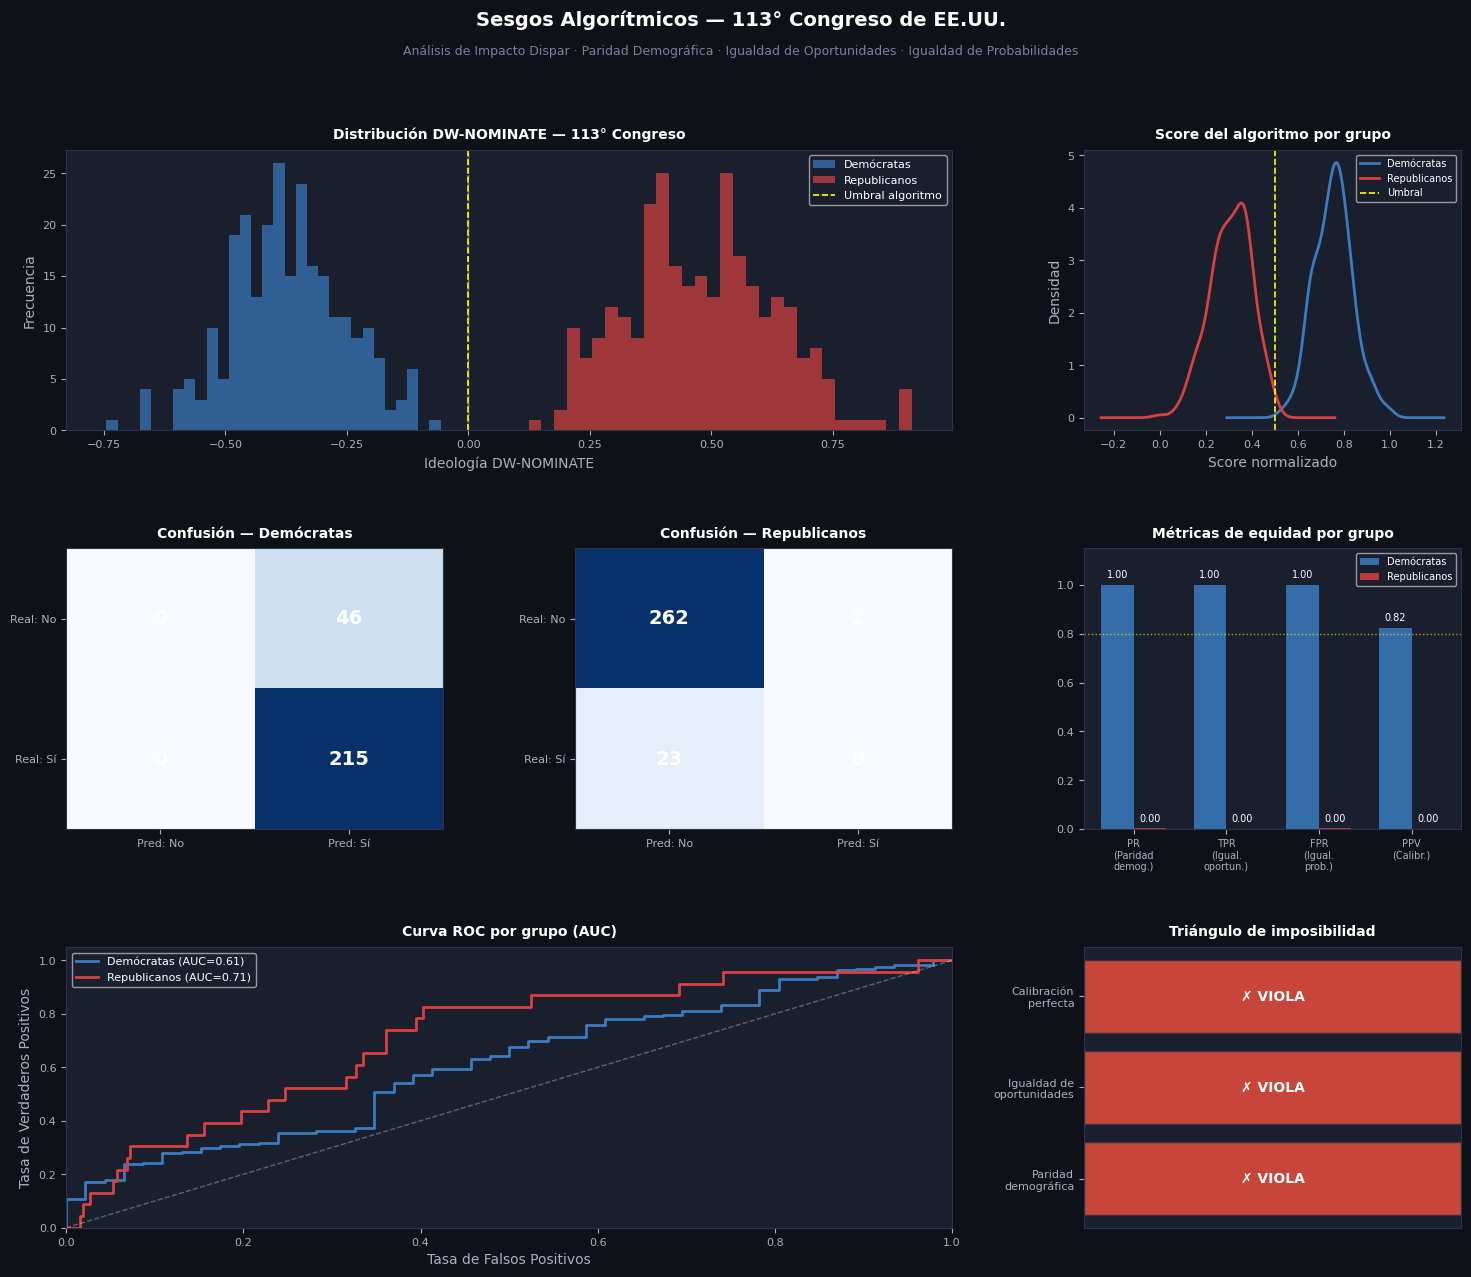


RESUMEN FINAL


In [8]:
import os
# 6. VISUALIZACIÓN
# ─────────────────────────────────────────────

COLOR_D = '#3a7cbf'
COLOR_R = '#d94040'
fig = plt.figure(figsize=(18, 14))
fig.patch.set_facecolor('#0e1117')
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.42, wspace=0.35)

def ax_style(ax, title):
    ax.set_facecolor('#1a1f2e')
    ax.set_title(title, color='white', fontsize=10, fontweight='bold', pad=8)
    ax.tick_params(colors='#aab0c0', labelsize=8)
    for spine in ax.spines.values():
        spine.set_color('#2d3348')
    ax.yaxis.label.set_color('#aab0c0')
    ax.xaxis.label.set_color('#aab0c0')
    return ax

# ── Panel 0: Distribución ideológica
ax0 = fig.add_subplot(gs[0, :2])
ax_style(ax0, "Distribución DW-NOMINATE — 113° Congreso")
for grp, color, label in [(dem, COLOR_D, 'Demócratas'), (rep, COLOR_R, 'Republicanos')]:
    ax0.hist(grp['ideology'], bins=30, color=color, alpha=0.7, label=label, edgecolor='none')
ax0.axvline(0, color='white', linestyle='--', alpha=0.4, linewidth=1)
ax0.axvline(float(UMBRAL * 2 - 1) * (-1), color='yellow', linestyle='--', linewidth=1.2, label=f'Umbral algoritmo')
ax0.set_xlabel('Ideología DW-NOMINATE')
ax0.set_ylabel('Frecuencia')
ax0.legend(fontsize=8, facecolor='#1a1f2e', labelcolor='white', framealpha=0.7)

# ── Panel 1: Score del algoritmo por grupo (KDE)
ax1 = fig.add_subplot(gs[0, 2])
ax_style(ax1, "Score del algoritmo por grupo")
for grp, color, label in [(dem, COLOR_D, 'Demócratas'), (rep, COLOR_R, 'Republicanos')]:
    grp['score_norm'].plot.kde(ax=ax1, color=color, linewidth=2, label=label)
ax1.axvline(UMBRAL, color='yellow', linestyle='--', linewidth=1.2, label='Umbral')
ax1.set_xlabel('Score normalizado')
ax1.set_ylabel('Densidad')
ax1.legend(fontsize=7, facecolor='#1a1f2e', labelcolor='white', framealpha=0.7)

# ── Panel 2: Confusion matrices lado a lado
for idx_ax, (grp_df, m, title) in enumerate([(dem, m_dem, 'Confusión — Demócratas'),
                                               (rep, m_rep, 'Confusión — Republicanos')]):
    ax = fig.add_subplot(gs[1, idx_ax])
    ax_style(ax, title)
    cm = np.array([[m['TN'], m['FP']], [m['FN'], m['TP']]])
    im = ax.imshow(cm, cmap='Blues', aspect='auto')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                    color='white', fontweight='bold', fontsize=14)
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['Pred: No', 'Pred: Sí'], color='#aab0c0', fontsize=8)
    ax.set_yticklabels(['Real: No', 'Real: Sí'], color='#aab0c0', fontsize=8)

# ── Panel 3: Comparación de métricas de equidad
ax3 = fig.add_subplot(gs[1, 2])
ax_style(ax3, "Métricas de equidad por grupo")
metricas_labels = ['PR\n(Paridad\ndemog.)', 'TPR\n(Igual.\noportun.)', 'FPR\n(Igual.\nprob.)', 'PPV\n(Calibr.)']
vals_dem = [m_dem['PR'], m_dem['TPR'], m_dem['FPR'], m_dem['PPV']]
vals_rep = [m_rep['PR'], m_rep['TPR'], m_rep['FPR'], m_rep['PPV']]
x = np.arange(len(metricas_labels))
w = 0.35
bars_d = ax3.bar(x - w/2, vals_dem, w, color=COLOR_D, alpha=0.85, label='Demócratas')
bars_r = ax3.bar(x + w/2, vals_rep, w, color=COLOR_R, alpha=0.85, label='Republicanos')
ax3.set_xticks(x); ax3.set_xticklabels(metricas_labels, fontsize=7)
ax3.set_ylim(0, 1.15)
ax3.axhline(0.8, color='yellow', linestyle=':', linewidth=1, alpha=0.6)
ax3.legend(fontsize=7, facecolor='#1a1f2e', labelcolor='white', framealpha=0.7)
for bar in list(bars_d) + list(bars_r):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{bar.get_height():.2f}', ha='center', va='bottom', color='white', fontsize=7)

# ── Panel 4: Curva ROC por grupo
ax4 = fig.add_subplot(gs[2, :2])
ax_style(ax4, "Curva ROC por grupo (AUC)")
from sklearn.metrics import roc_curve, auc
for grp, color, label in [(dem, COLOR_D, 'Demócratas'), (rep, COLOR_R, 'Republicanos')]:
    try:
        fpr_c, tpr_c, _ = roc_curve(grp['apoyo_real'], grp['score_norm'])
        roc_auc = auc(fpr_c, tpr_c)
        ax4.plot(fpr_c, tpr_c, color=color, linewidth=2, label=f'{label} (AUC={roc_auc:.2f})')
    except Exception:
        pass
ax4.plot([0, 1], [0, 1], 'w--', alpha=0.3, linewidth=1)
ax4.set_xlabel('Tasa de Falsos Positivos')
ax4.set_ylabel('Tasa de Verdaderos Positivos')
ax4.legend(fontsize=8, facecolor='#1a1f2e', labelcolor='white', framealpha=0.7)
ax4.set_xlim(0, 1); ax4.set_ylim(0, 1.05)

# ── Panel 5: Imposibilidad — trade-off visual
ax5 = fig.add_subplot(gs[2, 2])
ax_style(ax5, "Triángulo de imposibilidad")
criterios = ['Paridad\ndemográfica', 'Igualdad de\noportunidades', 'Calibración\nperfecta']
cumple = [int(diff_pr < 0.05), int(diff_tpr < 0.05), int(abs(ppv_dem - ppv_rep) < 0.05)]
colores = ['#2ecc71' if c else '#e74c3c' for c in cumple]
bars = ax5.barh(criterios, [1, 1, 1], color=colores, alpha=0.85, edgecolor='#2d3348')
for i, (c, label_c) in enumerate(zip(cumple, ['CUMPLE', 'VIOLA', 'VIOLA'])):
    ax5.text(0.5, i, '✓ CUMPLE' if c else '✗ VIOLA', ha='center', va='center',
             color='white', fontweight='bold', fontsize=10)
ax5.set_xlim(0, 1)
ax5.set_xticks([])
ax5.tick_params(axis='y', labelsize=8)

# Título general
fig.text(0.5, 0.98, 'Sesgos Algorítmicos — 113° Congreso de EE.UU.',
         ha='center', va='top', color='white', fontsize=14, fontweight='bold')
fig.text(0.5, 0.955, 'Análisis de Impacto Dispar · Paridad Demográfica · Igualdad de Oportunidades · Igualdad de Probabilidades',
         ha='center', va='top', color='#7a8299', fontsize=9)

# Create the directory if it doesn't exist
os.makedirs('/mnt/user-data/outputs/', exist_ok=True)
plt.savefig('/mnt/user-data/outputs/fairness_congress.png', dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
print("\n Figura guardada: fairness_congress.png")
plt.show()

print("\n" + "=" * 60)
print("RESUMEN FINAL")
print("=" * 60)

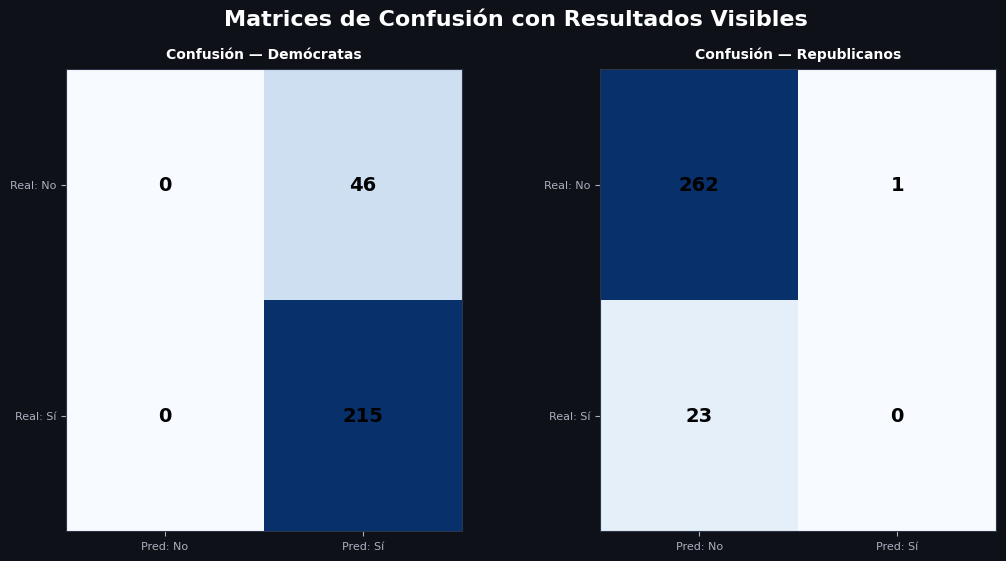

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.gridspec as gridspec

# Redefine ax_style for consistent formatting in this new plot
def ax_style(ax, title):
    ax.set_facecolor('#1a1f2e')
    ax.set_title(title, color='white', fontsize=10, fontweight='bold', pad=8)
    ax.tick_params(colors='#aab0c0', labelsize=8)
    for spine in ax.spines.values():
        spine.set_color('#2d3348')
    ax.yaxis.label.set_color('#aab0c0')
    ax.xaxis.label.set_color('#aab0c0')
    return ax

# Create a new figure for the confusion matrices
fig_cm = plt.figure(figsize=(12, 6))
fig_cm.patch.set_facecolor('#0e1117')
gs_cm = gridspec.GridSpec(1, 2, figure=fig_cm, wspace=0.35)

# Panel: Confusion matrices side-by-side
for idx_ax, (grp_df, m, title) in enumerate([(dem, m_dem, 'Confusión — Demócratas'),
                                               (rep, m_rep, 'Confusión — Republicanos')]):
    ax = fig_cm.add_subplot(gs_cm[0, idx_ax])
    ax_style(ax, title)
    cm = np.array([[m['TN'], m['FP']], [m['FN'], m['TP']]])
    im = ax.imshow(cm, cmap='Blues', aspect='auto')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                    color='black', fontweight='bold', fontsize=14) # Changed color to black for visibility
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['Pred: No', 'Pred: Sí'], color='#aab0c0', fontsize=8)
    ax.set_yticklabels(['Real: No', 'Real: Sí'], color='#aab0c0', fontsize=8)

fig_cm.suptitle('Matrices de Confusión con Resultados Visibles', color='white', fontsize=16, fontweight='bold')
plt.show()